# Wyżarzanie kwantowe

## Model Ising w polu poprzecznym
Tutaj $\sigma^z$ oraz $\sigma^x$ to, odpowiednio, macierze Pauliego zdefiniowane jako: 

$$
\sigma^z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}, \quad \sigma^x = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} 

$$ 
Warto pamiętać, że w przypadku działania macierzy Pauliego na spin zapis $\sigma^z_i$ oznacza

\begin{equation} \sigma^z_i = I \otimes I \otimes \ldots \otimes \sigma^z \otimes I \otimes \ldots \otimes I \end{equation}

Gdzie $\otimes$ jest iloczynem tensorowym (lub iloczynem Kroneckera)

## Twierdzenie adiabatyczne

Nie będziemy tutaj w pełni i formalnie formułować twierdzenia adiabatycznego mechaniki kwantowej. Na nasze potrzeby wystarczy rozumieć intuicyjnie.

Twierdzenie adiabatyczne (w mechanice kwantowej) z grubsza mówi, że, przy spełnieniu pewnych założeń, jeśli układ kwantowy znajduje się w stanie podstawowym pewnego hamiltonianu i ten hamiltonian zmienia się **wystarczająco powoli w czasie**, to układ pozostanie w odpowiadającym mu stanie podstawowym zmieniającego się hamiltonianu


## Sformułowanie wyżarzania kwantowego

W wyżarzaniu kwantowym wykorzystuje się to twierdzenie, aby znaleźć stan podstawowy (minimum globalne) hamiltonianu Isinga, który koduje problem optymalizacyjny. Proces wygląda tak:

1. Startujemy od prostego hamiltonianu $H_{initial}$​, którego stan podstawowy jest znany (np. prosta superpozycja).

2. Stopniowo  przekształcamy go w hamiltonian problemu $H_{problem}$​, którego minimum chcemy znaleźć.

3. Jeśli proces jest adiabatyczny (czyli wystarczająco powolny), to układ przejdzie z podstawowego stanu $H_{initial}$​ do podstawowego stanu $H_{problem}$​, dając rozwiązanie.

W maszynach D-Wave wyżarzanie kwantowe jest zaimplementowane w następujący sposób:

$$
\mathcal{H}(s) = A(s)H_{initial} + B(s)H_{Ising} = A(s)  \sum_{i}^{N} \sigma_i^x + B(s) ( \sum_{j < i} J_{ij} \sigma_i^z \sigma_j^z + \sum_{i=1}^{N} h_i \sigma_i^z )
$$

Przy założeniu że $A(s) \rightarrow 0$ i $B(s) \rightarrow 1$ oraz $s = t/\tau$

WIP

[[Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [0. 1. 1. 0.]], <function A at 0x7f1a70c3bce0>], [Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 2.  0.  0.  0.]
 [ 0. -1.  0.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0.  0.]], <function B at 0x7f1a6e93e200>]]


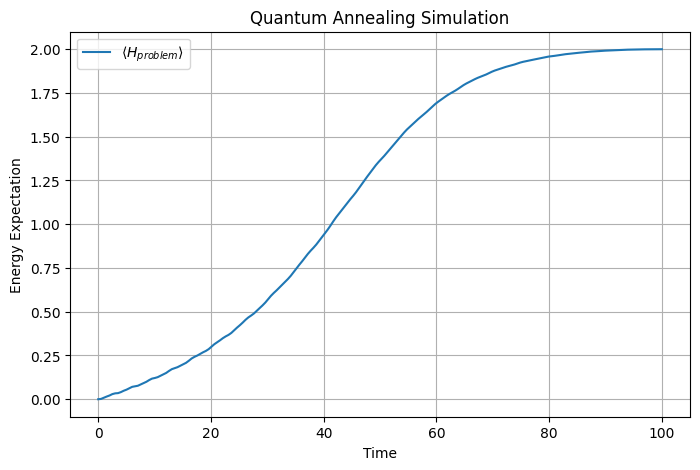

-1.0
(-1, 1)
Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[-0.40703415-9.13408597e-01j]
 [ 0.00141293-6.39092971e-04j]
 [ 0.00141293-6.39092971e-04j]
 [ 0.00163115-6.79203946e-04j]]
0.9999920684015722


In [ ]:
# Kod do symulacji wyżarzania kwantowego. W tej symulacji ewoluujemy równanie Schrödingera 

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from qutip import tensor, qeye, sigmax, sigmaz, basis, sesolve, ket2dm
from qutip.measurement import measure_observable
from itertools import product
from math import inf

# Rozmiar systemu
N = 2

# Konstruujemy odpowiednie operatory działające na odpowiednim qubicie
sx_list = []
sz_list = []
for qubit in range(N):
    op_list_x = [sigmax() if i==qubit else qeye(2) for i in range(N)]
    op_list_z = [sigmaz() if i==qubit else qeye(2) for i in range(N)]
    # z listy tworzymy jedna dużą macierz (operator) przez użycie iloczynu tensorowego
    sx_list.append(tensor(op_list_x))
    sz_list.append(tensor(op_list_z))
    

# Tworzymy  Hamiltonian początkowy H_initial 
H_initial = sum(sx_list)

# Tworzymy nasz klasyczny problem. Tutaj będzie każdy z każdym
problem_graph = nx.complete_graph(N)
J = {edge: 1 for edge in problem_graph.edges()}
h = {node: 0.5 for node in problem_graph.nodes()}

# Tworzymy hamiltonian probelmu

# H_problem = sum([J[edge] * sz_list[edge[0]] * sz_list[edge[1]] for edge in problem_graph.edges]) + \
#             sum([h[node] * sz_list[node] for node in problem_graph.nodes()])

# łatwiejszy
H_problem = sz_list[0] * sz_list[1] + 0.5 * (sz_list[0] + sz_list[1])



# Czas wyżarzania TODO: upewnij się co do jednostek
T = 100     # total annealing time
num_steps = 200
t_list = np.linspace(0, T, num_steps)

# Annealing schedules

# liniowy TODO: zaprogramój podobniejszy do d-wave
def A(t, args):
    return 1 - t/T

def B(t, args):
    return t/T

# Pełen hamiltonian H(t)
# H(t) = A(t)*H_initial + B(t)*H_problem
H_t = [[H_initial, A], [H_problem, B]]
print(H_t)

# Przygotuj stan podstawowy dla początkowego hamiltonianiu
# superpozycja n stanów |+>
state_plus = (basis(2, 0) + basis(2, 1)).unit()
psi0 = tensor([state_plus for _ in range(N)])

# symulacja, sledzimy przede wszystkim prawdopodobieństwa stanów
result = sesolve(H_t, psi0, t_list, e_ops=[H_problem], options={"store_states": True})
expect_H_problem = result.expect[0]


# plt.figure(figsize=(8, 5))
# plt.plot(t_list, expect_H_problem, label=r'$\langle H_{problem} \rangle$')
# plt.xlabel('Time')
# plt.ylabel('Energy Expectation')
# plt.title('Quantum Annealing Simulation')
# plt.legend()
# plt.grid(True)
# plt.show()

# Stan podstawowy z bruteforce
best_energy = inf
best_state = ()
for state in product([-1, 1], repeat=N):
    
    energy = sum([J[edge] * state[edge[0]] * state[edge[1]] for edge in problem_graph.edges]) + \
            sum([h[node] * state[node] for node in problem_graph.nodes()])
    if energy < best_energy:
        best_energy = energy
        best_state = state
print(best_energy)
print(best_state)


final_state = result.states[-1]
print(final_state)

up = basis(2, 0)

down = basis(2, 1)

phi = tensor(up, up)

probability = abs(final_state.overlap(phi)) ** 2
print(probability)
